# Laboratorio 7 — Spark MLlib
### CC3066 Data Science — Semestre II 2026
**Universidad del Valle de Guatemala — Facultad de Ingeniería**

**Integrantes del grupo**

| Integrante | Carné |
|---|---|
| Cindy Gualim | 21226 |
| Jose Donado |  |
| Daniela Ramírez |  |

---

Análisis de salarios de personas asalariadas con la base de **Personas** de la
Encuesta Nacional de Empleo e Ingresos Continua (ENEIC) del INE de Guatemala.
Se usan los cuatro trimestres de 2025 para desarrollo/entrenamiento y el
I trimestre de 2026 como prueba final.

## 1. Carga, armonización y calidad de datos

En esta sección:

1. Cargamos los cinco archivos de Excel identificando su procedencia.
2. Seleccionamos únicamente las columnas requeridas y homologamos sus tipos.
3. Unimos los cuatro archivos de 2025 con `unionByName`.
4. Documentamos faltantes, exclusiones por filtro y unicidad de la clave.
5. Guardamos los conjuntos preparados de 2025 y 2026 en Parquet.

> **Nota sobre el período:** la columna original `TRIMESTRE` **no** corresponde al
> trimestre calendario (I de 2025 trae el valor 2, y II de 2025 trae 3 y también 2
> en 175 registros). Por eso el período se deriva del **archivo de procedencia**,
> no de la columna, y la columna original se conserva solo para auditoría.

### 1.1 Configuración del entorno y sesión de Spark

In [1]:
import os, sys, glob

# Spark lanza procesos de Python para ejecutar el código del driver y de los
# workers. Fijar el intérprete evita que use uno distinto al del notebook
# (en Windows es la causa habitual del error "Python worker ... Accept timed out").
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
os.environ.setdefault("PYSPARK_DRIVER_PYTHON", sys.executable)

import pandas as pd
import numpy as np

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import (StructType, StructField, StringType,
                               DoubleType, IntegerType)

spark = (SparkSession.builder
         .appName("Lab7-ENEIC-SparkMLlib")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark:", spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 23:27:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1


### 1.2 Rutas y mapeo de archivos → período

`periodo_archivo`, `anio_archivo` y `trimestre_calendario` se construyen a partir
del archivo de origen. `archivo_origen` se conserva para trazabilidad.

In [2]:
DATA_DIR    = "data"      # carpeta con los .xlsx de la ENEIC (bases de Personas)
PARQUET_DIR = "parquet"   # salida intermedia
os.makedirs(PARQUET_DIR, exist_ok=True)

# periodo -> (año, trimestre calendario, uso previsto)
MAPEO_PERIODOS = {
    "2025T1": {"anio": 2025, "trimestre": 1, "uso": "entrenamiento"},
    "2025T2": {"anio": 2025, "trimestre": 2, "uso": "entrenamiento"},
    "2025T3": {"anio": 2025, "trimestre": 3, "uso": "entrenamiento"},
    "2025T4": {"anio": 2025, "trimestre": 4, "uso": "validacion"},
    "2026T1": {"anio": 2026, "trimestre": 1, "uso": "prueba final"},
}

print("Archivos disponibles en", DATA_DIR)
for f in sorted(glob.glob(os.path.join(DATA_DIR, "*.xls*"))):
    print("  -", os.path.basename(f))

Archivos disponibles en data
  - Base-de-datos-Personas-ENEIC-I-2026.xlsx
  - Base-de-datos-Personas-ENEIC-III-2025.xlsx
  - Base-de-datos-Personas-ENEIC-IV-2025.xlsx
  - Personas-ENEIC-T2-2025.xlsx
  - Personas_ENEIC_T1_2025.xlsx


El emparejamiento archivo → período se declara de forma **explícita** (los nombres de
archivo del INE varían), de modo que la asignación quede documentada y reproducible.

In [3]:
# Nombres tal como se descargaron del portal del INE
ARCHIVOS = {
    "2025T1": "Personas_ENEIC_T1_2025.xlsx",
    "2025T2": "Personas-ENEIC-T2-2025.xlsx",
    "2025T3": "Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "2025T4": "Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "2026T1": "Base-de-datos-Personas-ENEIC-I-2026.xlsx",
}

for p, nombre in ARCHIVOS.items():
    ruta = os.path.join(DATA_DIR, nombre)
    print(f"{p}: {'OK   ' if os.path.exists(ruta) else 'FALTA'} {ruta}")

2025T1: OK    data/Personas_ENEIC_T1_2025.xlsx
2025T2: OK    data/Personas-ENEIC-T2-2025.xlsx
2025T3: OK    data/Base-de-datos-Personas-ENEIC-III-2025.xlsx
2025T4: OK    data/Base-de-datos-Personas-ENEIC-IV-2025.xlsx
2026T1: OK    data/Base-de-datos-Personas-ENEIC-I-2026.xlsx


### 1.3 Columnas requeridas y tipos

| Original | Nombre analítico | Uso |
|---|---|---|
| P05D01 | salario_mensual | variable objetivo |
| P02A03 | edad | predictor numérico / clustering |
| P05C07A | antiguedad_anios | construcción de antigüedad |
| P05C07B | antiguedad_meses | construcción de antigüedad |
| P05H01A | horas_semanales | predictor / clustering |
| P03A03A | nivel_educativo | predictor categórico |
| P05C16 | categoria_ocupacional | filtro y predictor categórico |
| DOMINIO | dominio | predictor categórico |
| OCUPADOS | ocupado | filtro |
| NUM_HOGAR, NUM_PERSONA | (se conservan) | auditoría de registros |
| FACTOR | (se conserva) | diseño muestral |
| ANIO, TRIMESTRE | (se conservan) | auditoría de la fuente |

Un mismo código categórico puede llegar como número en un archivo y como texto en otro,
por lo que **se normaliza a texto** antes de unir.

In [4]:
COLS_NUM = {                      # original -> analítico (numéricas)
    "P05D01":  "salario_mensual",
    "P02A03":  "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
}
COLS_CAT = {                      # original -> analítico (categóricas, como texto)
    "P03A03A": "nivel_educativo",
    "P05C16":  "categoria_ocupacional",
    "DOMINIO": "dominio",
}
COLS_AUD = ["OCUPADOS", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE"]

COLS_ORIGINALES = list(COLS_NUM) + list(COLS_CAT) + COLS_AUD

ESQUEMA = StructType(
    [StructField(v, DoubleType(), True) for v in COLS_NUM.values()] +
    [StructField(v, StringType(), True) for v in COLS_CAT.values()] +
    [StructField("ocupado",     DoubleType(), True),
     StructField("NUM_HOGAR",   StringType(), True),
     StructField("NUM_PERSONA", StringType(), True),
     StructField("FACTOR",      DoubleType(), True),
     StructField("ANIO",        StringType(), True),
     StructField("TRIMESTRE",   StringType(), True),
     StructField("periodo_archivo",      StringType(),  True),
     StructField("anio_archivo",         IntegerType(), True),
     StructField("trimestre_calendario", IntegerType(), True),
     StructField("archivo_origen",       StringType(),  True)]
)

#### Función de carga

Cada archivo se lee **individualmente** con pandas/openpyxl (Spark no tiene lector nativo
de Excel), se convierte a DataFrame de Spark con tipos explícitos y se persiste en
Parquet. Procesarlos de uno en uno controla el consumo de memoria.

Criterios de tipificación:

- **Numéricas:** `pd.to_numeric(errors="coerce")`; los valores no evaluables quedan nulos
  y se **contabilizan** más adelante. No se imputa nada, y en particular no el salario.
- **Categóricas:** se normalizan a texto sin decimales sobrantes (`2.0` → `"2"`), se
  recorta el espacio en blanco y el vacío queda nulo para marcarse luego como
  `DESCONOCIDO`. El código educativo `0` ("ninguno") se preserva como categoría válida.

In [5]:
def _norm_cat(serie: pd.Series) -> pd.Series:
    """Normaliza un código categórico a texto consistente: 2, 2.0 y ' 2 ' -> '2'."""
    def f(v):
        if pd.isna(v):
            return None
        if isinstance(v, (int, np.integer)):
            return str(int(v))
        if isinstance(v, (float, np.floating)) and float(v).is_integer():
            return str(int(v))
        s = str(v).strip()
        if s == "":
            return None
        try:                        # '2.0' escrito como texto
            fv = float(s)
            if fv.is_integer():
                return str(int(fv))
        except ValueError:
            pass
        return s
    return serie.map(f)


def cargar_periodo(periodo):
    """Lee un archivo, selecciona y tipifica columnas, y lo guarda en Parquet."""
    meta   = MAPEO_PERIODOS[periodo]
    nombre = ARCHIVOS[periodo]
    ruta   = os.path.join(DATA_DIR, nombre)

    # usecols lee solo las columnas requeridas: baja el uso de memoria de
    # ~270 columnas a 14 y hace innecesario cargar el archivo completo en RAM.
    pdf = pd.read_excel(ruta, engine="openpyxl", usecols=COLS_ORIGINALES,
                        dtype=object)
    pdf.columns = [str(c).strip().upper() for c in pdf.columns]

    ausentes = [c for c in COLS_ORIGINALES if c not in pdf.columns]
    if ausentes:
        raise KeyError(f"{periodo}: faltan columnas {ausentes}")

    out = pd.DataFrame(index=pdf.index)
    for orig, nuevo in COLS_NUM.items():
        out[nuevo] = pd.to_numeric(pdf[orig], errors="coerce").astype("float64")
    for orig, nuevo in COLS_CAT.items():
        out[nuevo] = _norm_cat(pdf[orig])

    out["ocupado"]     = pd.to_numeric(pdf["OCUPADOS"], errors="coerce").astype("float64")
    out["NUM_HOGAR"]   = _norm_cat(pdf["NUM_HOGAR"])
    out["NUM_PERSONA"] = _norm_cat(pdf["NUM_PERSONA"])
    out["FACTOR"]      = pd.to_numeric(pdf["FACTOR"], errors="coerce").astype("float64")
    out["ANIO"]        = _norm_cat(pdf["ANIO"])
    out["TRIMESTRE"]   = _norm_cat(pdf["TRIMESTRE"])

    out["periodo_archivo"]      = periodo
    out["anio_archivo"]         = int(meta["anio"])
    out["trimestre_calendario"] = int(meta["trimestre"])
    out["archivo_origen"]       = nombre

    out = out[[f.name for f in ESQUEMA.fields]]

    # Se construyen tuplas de escalares de Python (NaN -> None) para no depender
    # del interoperador pandas<->Spark, sensible a la versión de pandas.
    def _py(v):
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return None
        if isinstance(v, np.generic):
            return v.item()
        return v

    filas = [tuple(_py(v) for v in fila)
             for fila in out.itertuples(index=False, name=None)]

    sdf = spark.createDataFrame(filas, schema=ESQUEMA)
    destino = os.path.join(PARQUET_DIR, f"crudo_{periodo}")
    sdf.write.mode("overwrite").parquet(destino)
    return spark.read.parquet(destino)

In [6]:
crudos = {}
conteos_originales = {}

for periodo in ARCHIVOS:
    crudos[periodo] = cargar_periodo(periodo)
    conteos_originales[periodo] = crudos[periodo].count()
    print(f"{periodo}: {conteos_originales[periodo]:,} registros cargados")

2025T1: 51,588 registros cargados


2025T2: 51,167 registros cargados


2025T3: 51,583 registros cargados


2025T4: 49,338 registros cargados


2026T1: 49,843 registros cargados


### 1.4 Unión de los cuatro archivos de 2025

Se usa `unionByName`, que empareja por **nombre** de columna y no por posición. Esto es
indispensable porque el archivo de IV de 2025 trae 302 columnas frente a 270 de los demás.
Como aquí ya seleccionamos el mismo subconjunto de columnas en todos los archivos los
esquemas coinciden; aun así se conserva `unionByName` por corrección y trazabilidad.

In [7]:
periodos_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]

df_2025 = crudos[periodos_2025[0]]
for p in periodos_2025[1:]:
    df_2025 = df_2025.unionByName(crudos[p], allowMissingColumns=True)

df_2026 = crudos["2026T1"]

df_2025.cache()
df_2026.cache()
print(f"2025 unido  : {df_2025.count():,} registros")
print(f"2026T1 (test): {df_2026.count():,} registros")

2025 unido  : 203,676 registros


2026T1 (test): 49,843 registros


#### Esquema y cinco registros de las columnas seleccionadas

In [8]:
df_2025.printSchema()

root
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: double (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)



In [9]:
df_2025.select("periodo_archivo", "archivo_origen", "ANIO", "TRIMESTRE",
               "trimestre_calendario", "salario_mensual", "edad",
               "antiguedad_anios", "antiguedad_meses", "horas_semanales",
               "nivel_educativo", "categoria_ocupacional", "dominio",
               "ocupado", "FACTOR").show(5, truncate=False)

+---------------+---------------------------+----+---------+--------------------+---------------+----+----------------+----------------+---------------+---------------+---------------------+-------+-------+------+
|periodo_archivo|archivo_origen             |ANIO|TRIMESTRE|trimestre_calendario|salario_mensual|edad|antiguedad_anios|antiguedad_meses|horas_semanales|nivel_educativo|categoria_ocupacional|dominio|ocupado|FACTOR|
+---------------+---------------------------+----+---------+--------------------+---------------+----+----------------+----------------+---------------+---------------+---------------------+-------+-------+------+
|2025T1         |Personas_ENEIC_T1_2025.xlsx|2025|2        |1                   |NULL           |80.0|NULL            |NULL            |NULL           |2              |NULL                 |2      |NULL   |519.0 |
|2025T1         |Personas_ENEIC_T1_2025.xlsx|2025|2        |1                   |NULL           |18.0|NULL            |NULL            |NULL    

#### Verificación del período

Comprobamos que la columna original `TRIMESTRE` no coincide con el trimestre calendario,
lo que justifica derivar el período del archivo de procedencia. Debe verse el valor 2 en
2025T1, los valores 3 y 2 en 2025T2, y así sucesivamente.

In [10]:
(df_2025.unionByName(df_2026)
        .groupBy("periodo_archivo", "anio_archivo", "trimestre_calendario", "TRIMESTRE")
        .count()
        .orderBy("periodo_archivo", "TRIMESTRE")
        .show(20, truncate=False))

+---------------+------------+--------------------+---------+-----+
|periodo_archivo|anio_archivo|trimestre_calendario|TRIMESTRE|count|
+---------------+------------+--------------------+---------+-----+
|2025T1         |2025        |1                   |2        |51588|
|2025T2         |2025        |2                   |2        |175  |
|2025T2         |2025        |2                   |3        |50992|
|2025T3         |2025        |3                   |4        |51583|
|2025T4         |2025        |4                   |5        |49338|
|2026T1         |2026        |1                   |6        |49843|
+---------------+------------+--------------------+---------+-----+



### 1.5 Faltantes por variable, **antes** de aplicar los filtros

In [11]:
def tabla_faltantes(df, etiqueta):
    total = df.count()
    cols = [c for c in df.columns
            if c not in ("periodo_archivo", "anio_archivo",
                         "trimestre_calendario", "archivo_origen")]
    conteos = df.select([
        F.count(F.when(F.col(c).isNull(), 1)).alias(c) for c in cols
    ]).collect()[0].asDict()

    out = (pd.DataFrame({"variable": list(conteos), "faltantes": list(conteos.values())})
             .assign(pct_faltantes=lambda d: (100 * d.faltantes / total).round(2))
             .sort_values("faltantes", ascending=False))
    out.insert(0, "conjunto", etiqueta)
    return out


faltantes = pd.concat([tabla_faltantes(df_2025, "2025 (train)"),
                       tabla_faltantes(df_2026, "2026T1 (test)")],
                      ignore_index=True)
faltantes

,conjunto,variable,faltantes,pct_faltantes
0,2025 (train),salario_mensual,150651,73.97
1,2025 (train),antiguedad_anios,115454,56.69
2,2025 (train),horas_semanales,115454,56.69
3,2025 (train),antiguedad_meses,115454,56.69
4,2025 (train),ocupado,115454,56.69
5,2025 (train),categoria_ocupacional,115454,56.69
6,2025 (train),nivel_educativo,26344,12.93
7,2025 (train),edad,0,0.00
8,2025 (train),dominio,0,0.00
9,2025 (train),NUM_HOGAR,0,0.00


**Interpretación.** Los porcentajes altos en `salario_mensual`, `antiguedad_*` y
`horas_semanales` son esperables: esas preguntas solo aplican a personas ocupadas y
asalariadas, de modo que la mayor parte de esos "faltantes" en el archivo completo son en
realidad *no aplica* (la pregunta no correspondía a esa persona), no respuestas perdidas.
Por eso la tabla se calcula **antes** de filtrar: una vez restringidos a la población
analítica, el faltante residual sí representa no respuesta.

### 1.6 Construcción de la antigüedad

$$\text{antigüedad (años)} = \text{antiguedad\_anios} + \frac{\text{antiguedad\_meses}}{12}$$

In [12]:
def derivar_antiguedad(df):
    return df.withColumn(
        "antiguedad",
        F.when(F.col("antiguedad_anios").isNotNull() & F.col("antiguedad_meses").isNotNull(),
               F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)))

df_2025 = derivar_antiguedad(df_2025)
df_2026 = derivar_antiguedad(df_2026)
df_2025.select("antiguedad_anios", "antiguedad_meses", "antiguedad").show(5)

+----------------+----------------+----------+
|antiguedad_anios|antiguedad_meses|antiguedad|
+----------------+----------------+----------+
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
+----------------+----------------+----------+
only showing top 5 rows



### 1.7 Filtrado secuencial de la población analítica

Se aplica **siempre el mismo orden** y se contabiliza cuántos registros se excluyen en
cada paso. No se imputa el salario ni se eliminan valores extremos.

| # | Filtro |
|---|---|
| 1 | Edad finita y ≥ 15 |
| 2 | Ocupado (`OCUPADOS = 1`) |
| 3 | Asalariado (`P05C16` ∈ {1, 2, 3, 4}) |
| 4 | `salario_mensual` numérico, finito y estrictamente positivo |
| 5 | Antigüedad en años no negativa |
| 6 | Componente de meses entero entre 0 y 11 |
| 7 | Antigüedad calculada ≤ edad |
| 8 | Horas habituales > 0 y ≤ 168 |

In [13]:
FILTROS = [
    ("1. edad finita y >= 15",
     lambda d: d.filter(F.col("edad").isNotNull() & ~F.isnan("edad")
                        & (F.col("edad") >= 15))),
    ("2. ocupado (OCUPADOS = 1)",
     lambda d: d.filter(F.col("ocupado") == 1)),
    ("3. asalariado (P05C16 in 1..4)",
     lambda d: d.filter(F.col("categoria_ocupacional").isin("1", "2", "3", "4"))),
    ("4. salario finito y > 0",
     lambda d: d.filter(F.col("salario_mensual").isNotNull()
                        & ~F.isnan("salario_mensual")
                        & (F.col("salario_mensual") > 0)
                        & (F.col("salario_mensual") < float("inf")))),
    ("5. antiguedad_anios >= 0",
     lambda d: d.filter(F.col("antiguedad_anios").isNotNull()
                        & (F.col("antiguedad_anios") >= 0))),
    ("6. antiguedad_meses entero 0..11",
     lambda d: d.filter(F.col("antiguedad_meses").isNotNull()
                        & (F.col("antiguedad_meses") >= 0)
                        & (F.col("antiguedad_meses") <= 11)
                        & (F.col("antiguedad_meses") == F.floor("antiguedad_meses")))),
    ("7. antiguedad <= edad",
     lambda d: d.filter(F.col("antiguedad") <= F.col("edad"))),
    ("8. horas_semanales en (0, 168]",
     lambda d: d.filter(F.col("horas_semanales").isNotNull()
                        & ~F.isnan("horas_semanales")
                        & (F.col("horas_semanales") > 0)
                        & (F.col("horas_semanales") <= 168))),
]


def aplicar_filtros(df, etiqueta):
    actual = df
    n_prev = actual.count()
    filas = [{"conjunto": etiqueta, "paso": "0. original",
              "registros": n_prev, "excluidos": 0}]
    for nombre, f in FILTROS:
        actual = f(actual)
        n = actual.count()
        filas.append({"conjunto": etiqueta, "paso": nombre,
                      "registros": n, "excluidos": n_prev - n})
        n_prev = n
    return actual, pd.DataFrame(filas)

In [14]:
analitico_2025, traza_2025 = aplicar_filtros(df_2025, "2025 (train)")
analitico_2026, traza_2026 = aplicar_filtros(df_2026, "2026T1 (test)")

analitico_2025.cache()
analitico_2026.cache()

traza = pd.concat([traza_2025, traza_2026], ignore_index=True)
traza

,conjunto,paso,registros,excluidos
0,2025 (train),0. original,203676,0
1,2025 (train),1. edad finita y >= 15,140790,62886
2,2025 (train),2. ocupado (OCUPADOS = 1),88222,52568
3,2025 (train),3. asalariado (P05C16 in 1..4),53025,35197
4,2025 (train),4. salario finito y > 0,53025,0
5,2025 (train),5. antiguedad_anios >= 0,53025,0
6,2025 (train),6. antiguedad_meses entero 0..11,53025,0
7,2025 (train),7. antiguedad <= edad,53025,0
8,2025 (train),"8. horas_semanales en (0, 168]",53025,0
9,2026T1 (test),0. original,49843,0


#### Registros por archivo, antes y después de los filtros

In [15]:
antes = (df_2025.unionByName(df_2026)
         .groupBy("periodo_archivo").count()
         .withColumnRenamed("count", "antes_filtros"))
despues = (analitico_2025.unionByName(analitico_2026)
           .groupBy("periodo_archivo").count()
           .withColumnRenamed("count", "despues_filtros"))

(antes.join(despues, "periodo_archivo", "left")
      .fillna(0, subset=["despues_filtros"])
      .withColumn("retencion_pct",
                  F.round(100 * F.col("despues_filtros") / F.col("antes_filtros"), 2))
      .orderBy("periodo_archivo")
      .show(truncate=False))

+---------------+-------------+---------------+-------------+
|periodo_archivo|antes_filtros|despues_filtros|retencion_pct|
+---------------+-------------+---------------+-------------+
|2025T1         |51588        |13419          |26.01        |
|2025T2         |51167        |13492          |26.37        |
|2025T3         |51583        |13450          |26.07        |
|2025T4         |49338        |12664          |25.67        |
|2026T1         |49843        |13258          |26.6         |
+---------------+-------------+---------------+-------------+



**Interpretación.** La caída más grande ocurre en los pasos 2 y 3: la base de Personas
incluye a toda la población del hogar, y solo una fracción es ocupada **y** asalariada.
Las exclusiones posteriores (pasos 4 a 8) son de calidad de dato y deben ser
comparativamente pequeñas; si alguna resultara grande, conviene revisarla antes de
modelar porque estaría recortando la población analítica de forma no aleatoria.

### 1.8 Normalización de categóricas: `DESCONOCIDO`

Los valores ausentes o no reconocidos frente al diccionario se representan como
`DESCONOCIDO`, **no** como cero. En particular, el código educativo `0` significa
"ninguno" y es una categoría válida que se conserva.

In [16]:
# Códigos válidos según el diccionario de datos de la ENEIC
# (verificados contra los cinco archivos: educación 0-7, dominio 1-3).
CODIGOS_VALIDOS = {
    "nivel_educativo":       [str(i) for i in range(0, 8)],    # 0 = ninguno
    "categoria_ocupacional": ["1", "2", "3", "4"],
    "dominio":               ["1", "2", "3"],
}


def marcar_desconocido(df):
    for col, validos in CODIGOS_VALIDOS.items():
        df = df.withColumn(
            col,
            F.when(F.col(col).isNotNull() & F.col(col).isin(validos), F.col(col))
             .otherwise(F.lit("DESCONOCIDO")))
    return df


analitico_2025 = marcar_desconocido(analitico_2025)
analitico_2026 = marcar_desconocido(analitico_2026)

for col in CODIGOS_VALIDOS:
    print(f"--- {col} (2025) ---")
    analitico_2025.groupBy(col).count().orderBy(F.desc("count")).show(15, truncate=False)

--- nivel_educativo (2025) ---


+---------------+-----+
|nivel_educativo|count|
+---------------+-----+
|4              |16851|
|2              |15822|
|3              |8249 |
|5              |6818 |
|0              |3995 |
|6              |771  |
|1              |459  |
|7              |60   |
+---------------+-----+

--- categoria_ocupacional (2025) ---


+---------------------+-----+
|categoria_ocupacional|count|
+---------------------+-----+
|2                    |28702|
|3                    |13842|
|1                    |6575 |
|4                    |3906 |
+---------------------+-----+

--- dominio (2025) ---


+-------+-----+
|dominio|count|
+-------+-----+
|1      |22072|
|2      |20146|
|3      |10807|
+-------+-----+



> Si aparece un volumen notable de `DESCONOCIDO`, es señal de que el rango de códigos
> asumido arriba no coincide con el diccionario de datos y debe corregirse antes de
> modelar: no es un faltante real, sino un error de configuración.

### 1.9 Unicidad de la clave (`periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`)

No se usa `dropDuplicates()`. Si aparecen claves repetidas se investiga si son
repeticiones **exactas** o registros en **conflicto**.

In [17]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]


def revisar_unicidad(df, etiqueta):
    dups = df.groupBy(*CLAVE).count().filter(F.col("count") > 1)
    n_claves = dups.count()
    n_filas = dups.agg(F.coalesce(F.sum("count"), F.lit(0))).collect()[0][0]
    print(f"[{etiqueta}] claves duplicadas: {n_claves:,} | filas involucradas: {n_filas:,}")
    if n_claves == 0:
        print("   la clave es única dentro de cada período")
        return None

    filas_dup = df.join(dups.select(*CLAVE), CLAVE, "inner")
    cols_cmp = [c for c in df.columns if c not in CLAVE]
    exactos = (filas_dup.groupBy(*CLAVE, *cols_cmp).count()
                        .filter(F.col("count") > 1)
                        .agg(F.coalesce(F.sum("count"), F.lit(0)))
                        .collect()[0][0])
    print(f"   filas que son repetición exacta : {exactos:,}")
    print(f"   filas en conflicto (difieren)   : {n_filas - exactos:,}")
    filas_dup.orderBy(*CLAVE).show(10, truncate=False)
    return filas_dup


dup_2025 = revisar_unicidad(analitico_2025, "2025 (train)")
dup_2026 = revisar_unicidad(analitico_2026, "2026T1 (test)")

[2025 (train)] claves duplicadas: 0 | filas involucradas: 0
   la clave es única dentro de cada período


[2026T1 (test)] claves duplicadas: 0 | filas involucradas: 0
   la clave es única dentro de cada período


Una repetición **exacta** es redundancia del archivo y puede documentarse y consolidarse
con criterio explícito. Un registro **en conflicto** (misma clave, valores distintos) es
un problema de identidad que no se resuelve borrando una fila al azar: o la clave no
identifica de forma única a la persona dentro del período, o hay un error de captura. En
ambos casos se documenta en lugar de ocultarse con `dropDuplicates()`.

In [18]:
# La persona SÍ puede repetirse ENTRE períodos: la ENEIC es un panel con rotación.
(analitico_2025.groupBy("NUM_HOGAR", "NUM_PERSONA")
 .agg(F.countDistinct("periodo_archivo").alias("n_periodos"))
 .groupBy("n_periodos").count()
 .orderBy("n_periodos")
 .show())

+----------+-----+
|n_periodos|count|
+----------+-----+
|         1|11303|
|         2| 7831|
|         3| 4240|
|         4| 3335|
+----------+-----+



El conteo anterior muestra en cuántos trimestres aparece cada combinación
hogar–persona. Que buena parte aparezca en más de un período es consistente con el
**diseño longitudinal con rotación** de la encuesta, y no constituye un error de datos.

### 1.10 Respuestas a las preguntas de la sección

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**

Porque tiene **302 columnas** frente a las 270 de los demás. Un apilado por posición
(`union` de Spark, que empareja por índice) alinearía la columna *k* de un archivo con la
columna *k* del otro, y a partir de la primera columna adicional todas quedarían
desplazadas: los valores de una variable terminarían almacenados bajo el nombre de otra,
mezclando tipos y, en el peor caso, sin arrojar ningún error visible. `unionByName`
empareja por **nombre**, que es la única forma correcta cuando los esquemas difieren.
Adicionalmente, aquí preseleccionamos el mismo subconjunto de columnas en todos los
archivos, lo que hace la unión robusta a ese cambio de estructura.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una
respuesta no registrada?**

El *no aplica* es estructural: la pregunta nunca se le hizo a esa persona porque un filtro
previo del cuestionario la excluía —a quien no es asalariado no se le pregunta el salario
de la ocupación principal—. Su ausencia es informativa y **no debe imputarse**, porque el
valor simplemente no existe. La *no respuesta* ocurre cuando la pregunta sí correspondía
pero la persona no contestó o el dato no se registró; ahí sí hay un valor real
desconocido, y su ausencia puede introducir sesgo si no es aleatoria. Operativamente los
distinguimos por el orden de filtrado: lo ausente **antes** de restringir a la población
asalariada es mayoritariamente *no aplica*; lo que sigue ausente **dentro** de esa
población es no respuesta.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del
conjunto longitudinal?**

Porque la unidad de análisis es la **persona-período**, no la persona. La ENEIC es un
panel con rotación: por diseño una misma vivienda se entrevista en varios trimestres
consecutivos. Sus dos registros son observaciones distintas —distinto trimestre, y
posiblemente distinto salario, antigüedad y jornada— y borrar una destruiría justamente la
variación temporal que hace útil el panel, además de sesgar la composición de la muestra
hacia los hogares que rotan más rápido. El duplicado problemático es otro: la misma clave
**dentro del mismo período**, que es exactamente lo que verifica la sección 1.9.

**¿Por qué el número de registros de la base filtrada no representa a todos los
trabajadores del país?**

Por tres razones acumuladas. (i) Es una **muestra**, no un censo: cada registro representa
a muchas personas mediante `FACTOR`, y nuestros conteos son sin ponderar. (ii)
Restringimos deliberadamente la población a asalariados de 15 años o más con salario
positivo registrado, lo que excluye por construcción a trabajadores por cuenta propia,
patronos, familiares no remunerados y a quienes no reportaron salario. (iii) Los filtros
de calidad eliminan además registros con valores inválidos o no evaluables, que no son una
submuestra aleatoria. Por eso los resultados describen **los registros analizados** y no
deben presentarse como estimaciones oficiales de la población guatemalteca.

**¿Para qué se utilizaría `FACTOR`?**

`FACTOR` es el factor de expansión del diseño muestral: indica a cuántas personas de la
población representa cada registro. En un análisis **poblacional** se usaría para ponderar
totales, medias y medianas —por ejemplo, el salario mediano de los asalariados del país— y,
junto con los estratos y las unidades primarias de muestreo, para estimar errores estándar
e intervalos de confianza correctos. En este laboratorio lo **conservamos pero no lo
usamos**, para mantener un alcance uniforme y no ponderado; tampoco entra como predictor
en los modelos.

### 1.11 Guardado en Parquet

Se guardan por separado el conjunto preparado de 2025 y el de 2026. Estos son el único
insumo de las secciones siguientes, de modo que el notebook puede ejecutarse de principio
a fin sin depender de variables creadas manualmente.

In [19]:
RUTA_2025 = os.path.join(PARQUET_DIR, "analitico_2025")
RUTA_2026 = os.path.join(PARQUET_DIR, "analitico_2026T1")

analitico_2025.write.mode("overwrite").parquet(RUTA_2025)
analitico_2026.write.mode("overwrite").parquet(RUTA_2026)

print(f"2025   -> {RUTA_2025}   ({spark.read.parquet(RUTA_2025).count():,} registros)")
print(f"2026T1 -> {RUTA_2026}   ({spark.read.parquet(RUTA_2026).count():,} registros)")

2025   -> parquet/analitico_2025   (53,025 registros)


2026T1 -> parquet/analitico_2026T1   (13,258 registros)


**Resumen de la sección 1.** Los cinco archivos se cargaron individualmente, se
tipificaron de forma explícita y se unieron por nombre de columna. El período se derivó
del archivo de procedencia y no de la columna `TRIMESTRE`, que se conserva únicamente para
auditoría. Se documentaron los faltantes previos al filtrado, el número de registros
excluidos en cada paso de un filtrado de orden fijo, y la unicidad de la clave
período–hogar–persona sin recurrir a `dropDuplicates()`. Los conjuntos preparados quedaron
guardados en Parquet y son el insumo de las secciones siguientes.

## 2. Estadística descriptiva y preguntas de exploración

Se trabaja con la población analítica de 2025 guardada en Parquet. Las estadísticas se
calculan con Spark sobre el conjunto completo; a pandas solo pasan tablas agregadas o una
muestra de hasta 8,000 registros para el histograma.

In [20]:
import matplotlib.pyplot as plt

df = spark.read.parquet(RUTA_2025).cache()
N_2025 = df.count()
VARS_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

ETQ_CATEGORIA = {"1": "Gobierno", "2": "Empresa privada",
                 "3": "Jornalero/peón", "4": "Servicio doméstico"}
print(f"Población analítica 2025: {N_2025:,} registros")

Población analítica 2025: 53,025 registros


### 2.1 Resumen de las variables numéricas

In [21]:
def resumen(df, cols):
    filas = []
    for c in cols:
        r = df.agg(F.count(c).alias("n"), F.mean(c).alias("media"),
                   F.stddev(c).alias("desv_est"), F.min(c).alias("min"),
                   F.max(c).alias("max"),
                   F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias("p")).first()
        filas.append({"variable": c, "n": r["n"], "media": r["media"], "mediana": r["p"][1],
                      "desv_est": r["desv_est"], "min": r["min"], "p25": r["p"][0],
                      "p75": r["p"][2], "p95": r["p"][3], "max": r["max"]})
    return pd.DataFrame(filas).set_index("variable").round(2)

resumen_2025 = resumen(df, VARS_NUM)
resumen_2025

,n,media,mediana,desv_est,min,p25,p75,p95,max
variable,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0
edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0
antiguedad,53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0
horas_semanales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0


Se usa `percentile` (exacto) y no `percentile_approx`: el volumen de 2025 lo permite, y
así la mediana y los percentiles no arrastran error de aproximación.

### 2.2 Distribución de registros por categoría ocupacional, nivel educativo y dominio

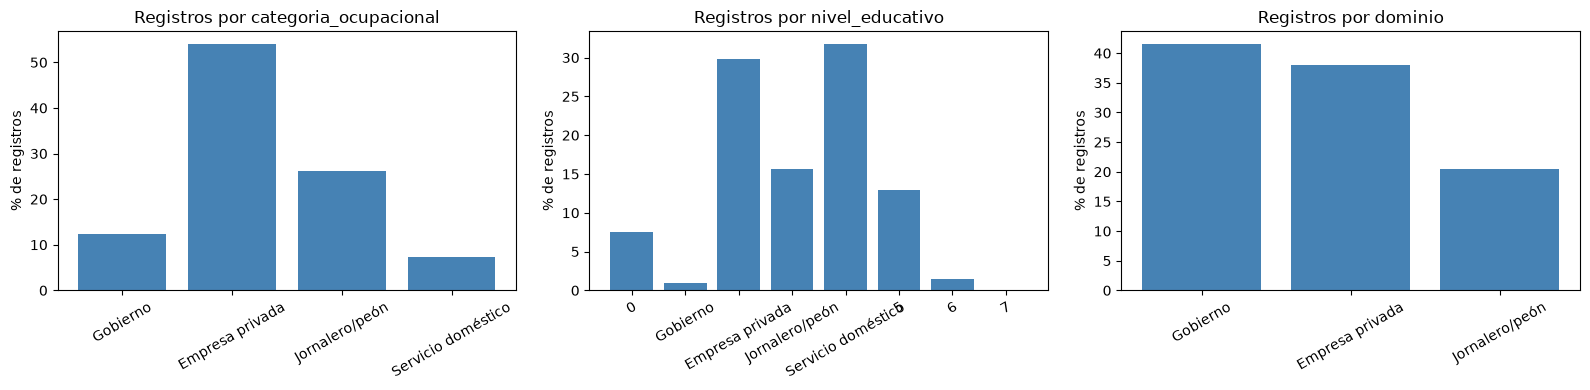

In [22]:
def conteo(df, col):
    return (df.groupBy(col).count()
              .withColumn("pct", F.round(100 * F.col("count") / N_2025, 1))
              .orderBy(col).toPandas())

fig, ejes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(ejes, ["categoria_ocupacional", "nivel_educativo", "dominio"]):
    t = conteo(df, col)
    etiquetas = t[col].map(ETQ_CATEGORIA).fillna(t[col])
    ax.bar(etiquetas, t["pct"], color="steelblue")
    ax.set_title(f"Registros por {col}")
    ax.set_ylabel("% de registros")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Interpretación.** La muestra no está balanceada. Por categoría ocupacional, empresa
privada concentra el 54 % de los registros, seguida de jornaleros/peones (26 %),
gobierno (12 %) y servicio doméstico (7 %). En educación dominan los códigos 4 (32 %) y
2 (30 %), mientras que los niveles 6 y 7 son muy pequeños (771 y 60 registros), así que
sus medianas son poco estables. Por dominio, el 1 y el 2 suman cerca del 80 % y el 3
tiene alrededor del 20 %.

### 2.3 Forma de la distribución del salario

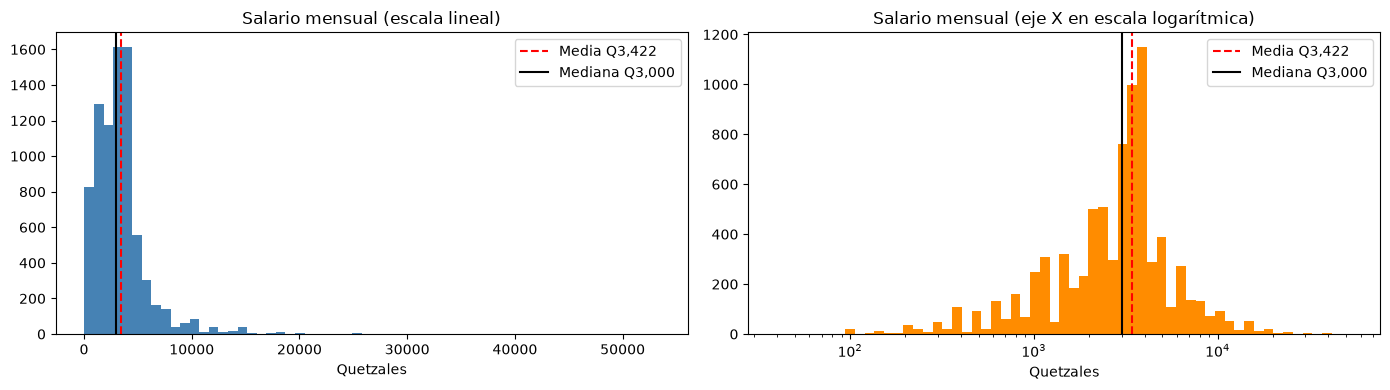

Media - mediana = Q421.68  |  media / mediana = 1.14


In [23]:
muestra = (df.select("salario_mensual")
             .sample(fraction=min(1.0, 8000 / N_2025), seed=42)
             .toPandas()["salario_mensual"])

media, mediana = resumen_2025.loc["salario_mensual", ["media", "mediana"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(muestra, bins=60, color="steelblue")
ax1.set_title("Salario mensual (escala lineal)")
ax2.hist(muestra, bins=np.logspace(np.log10(muestra.min()), np.log10(muestra.max()), 60),
         color="darkorange")
ax2.set_xscale("log")
ax2.set_title("Salario mensual (eje X en escala logarítmica)")
for ax in (ax1, ax2):
    ax.axvline(media, color="red", ls="--", label=f"Media Q{media:,.0f}")
    ax.axvline(mediana, color="black", label=f"Mediana Q{mediana:,.0f}")
    ax.set_xlabel("Quetzales")
    ax.legend()
plt.tight_layout()
plt.show()

print(f"Media - mediana = Q{media - mediana:,.2f}  |  media / mediana = {media / mediana:.2f}")

**Interpretación.** La distribución es **asimétrica a la derecha**. La mitad de los
asalariados gana entre Q1,800 y Q4,000 y el percentil 95 es Q8,000, pero la cola llega
hasta Q99,000. La **media (Q3,422) supera a la mediana (Q3,000) en Q422**, alrededor de un
14 %. La brecha no es mayor porque los valores extremos son pocos frente a una gran masa
concentrada en montos redondos (Q3,000, Q4,000). También hay salarios muy bajos (mínimo
de Q1), probablemente pagos parciales o errores de registro. No se eliminan, pero van a
inflar el RMSE de los modelos. En escala logarítmica la forma es casi simétrica. Esa
escala es solo para visualizar, porque el modelado usa quetzales.

### 2.4 Salario mediano por nivel educativo y por categoría ocupacional

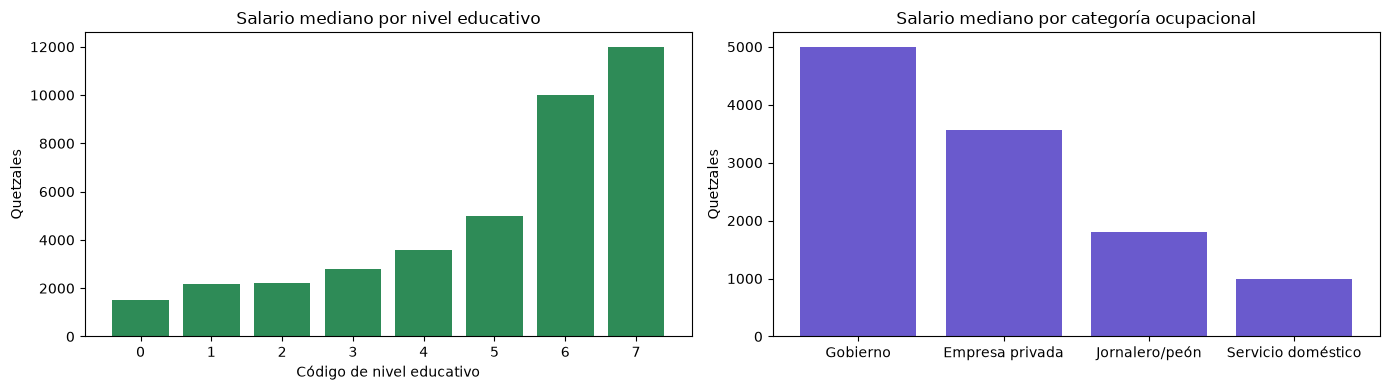

,nivel_educativo,n,salario_mediano
0,0,3995,1500.0
1,1,459,2160.0
2,2,15822,2200.0
3,3,8249,2800.0
4,4,16851,3600.0
5,5,6818,5000.0
6,6,771,10000.0
7,7,60,12000.0


,categoria_ocupacional,n,salario_mediano,etiqueta
0,1,6575,5000.0,Gobierno
1,2,28702,3567.5,Empresa privada
2,3,13842,1800.0,Jornalero/peón
3,4,3906,1000.0,Servicio doméstico


In [24]:
def mediana_por(df, col):
    return (df.groupBy(col)
              .agg(F.count("*").alias("n"),
                   F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"))
              .orderBy(col).toPandas())

med_edu = mediana_por(df, "nivel_educativo")
med_cat = mediana_por(df, "categoria_ocupacional")
med_cat["etiqueta"] = med_cat["categoria_ocupacional"].map(ETQ_CATEGORIA).fillna(med_cat["categoria_ocupacional"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(med_edu["nivel_educativo"], med_edu["salario_mediano"], color="seagreen")
ax1.set_title("Salario mediano por nivel educativo")
ax1.set_xlabel("Código de nivel educativo")
ax2.bar(med_cat["etiqueta"], med_cat["salario_mediano"], color="slateblue")
ax2.set_title("Salario mediano por categoría ocupacional")
for ax in (ax1, ax2):
    ax.set_ylabel("Quetzales")
plt.tight_layout()
plt.show()

display(med_edu, med_cat)

**Interpretación.** El salario mediano crece de forma casi escalonada con la educación:
pasa de Q1,500 sin estudios (código 0) a Q3,600 en el código 4, Q5,000 en el 5 y entre
Q10,000 y Q12,000 en los niveles 6 y 7. Por categoría la brecha también es marcada:
gobierno (Q5,000) > empresa privada (Q3,568) > jornalero (Q1,800) > servicio doméstico
(Q1,000). Son asociaciones, no efectos causales, porque educación y categoría están
relacionadas entre sí. Los niveles 6 y 7 tienen pocos casos y deben leerse con cautela.

### 2.5 Tamaño de la muestra y salario mediano por trimestre

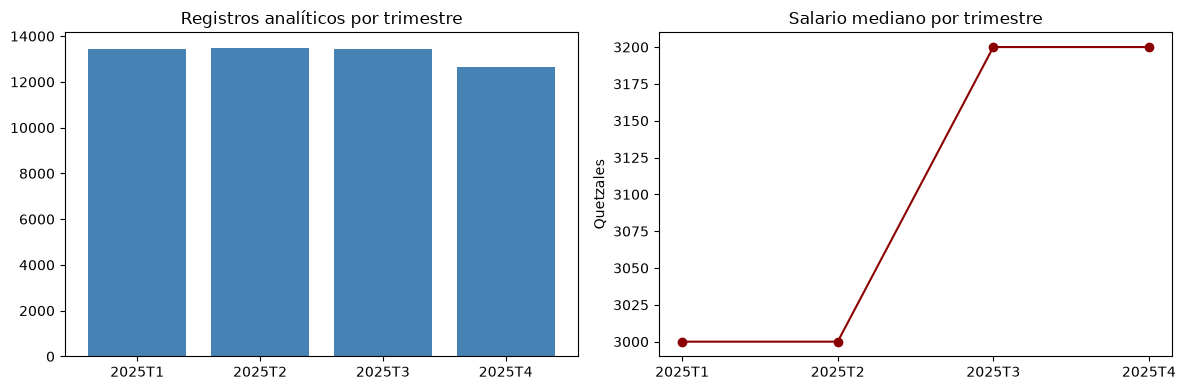

,periodo_archivo,n,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


In [25]:
por_trim = (df.groupBy("periodo_archivo")
              .agg(F.count("*").alias("n"),
                   F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"))
              .orderBy("periodo_archivo").toPandas())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(por_trim["periodo_archivo"], por_trim["n"], color="steelblue")
ax1.set_title("Registros analíticos por trimestre")
ax2.plot(por_trim["periodo_archivo"], por_trim["salario_mediano"], marker="o", color="darkred")
ax2.set_title("Salario mediano por trimestre")
ax2.set_ylabel("Quetzales")
plt.tight_layout()
plt.show()
por_trim

**Interpretación.** La muestra analítica es estable: unos 13,400 registros en T1–T3 y
12,664 en T4, que es el archivo más pequeño. El salario mediano pasa de Q3,000 en T1–T2 a
Q3,200 en T3–T4. Es un cambio leve, compatible con la rotación del panel o con ajustes
salariales, y no altera la distribución general. Esa estabilidad respalda entrenar con
T1–T3, validar con T4 y probar en 2026T1.

## 3. Relaciones entre variables numéricas

Se ensamblan las cuatro variables con `VectorAssembler` y se calcula la correlación de
**Pearson** con `Correlation.corr()` sobre todos los registros elegibles de 2025.

In [26]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

vec = (VectorAssembler(inputCols=VARS_NUM, outputCol="vars")
       .transform(df).select("vars"))
matriz = Correlation.corr(vec, "vars", method="pearson").head()[0].toArray()

corr_df = pd.DataFrame(matriz, index=VARS_NUM, columns=VARS_NUM).round(3)
corr_df

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


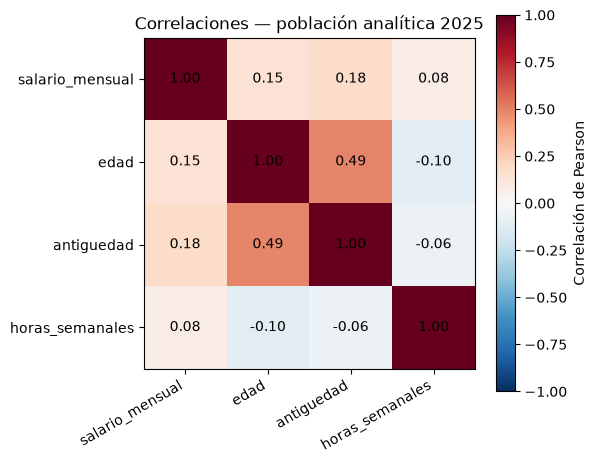

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(VARS_NUM)))
ax.set_xticklabels(VARS_NUM, rotation=30, ha="right")
ax.set_yticks(range(len(VARS_NUM)))
ax.set_yticklabels(VARS_NUM)
for i in range(len(VARS_NUM)):
    for j in range(len(VARS_NUM)):
        ax.text(j, i, f"{corr_df.iat[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Correlación de Pearson")
ax.set_title("Correlaciones — población analítica 2025")
plt.tight_layout()
plt.show()

**Interpretación.**

- **Asociación con el salario:** todas las correlaciones con el salario son débiles. La
  más alta es la de la antigüedad (0.18), seguida de la edad (0.15). Las horas casi no se
  relacionan (0.08), porque muchas jornadas largas corresponden a empleos mal pagados. La
  asimetría y los extremos del salario también atenúan la correlación de Pearson.
- **Edad y antigüedad:** tienen una relación positiva moderada (0.49), la más fuerte de la
  matriz, ya que la antigüedad crece con la edad. No llega a ser una colinealidad
  grave, pero conviene tenerla presente al leer los coeficientes de la regresión.

Con relaciones lineales tan débiles, gran parte del poder predictivo tendrá que venir de
las variables categóricas (educación y categoría ocupacional) o de relaciones no
lineales, lo que favorece a Random Forest.

## 4. Segmentación de perfiles mediante KMeans

Se estandarizan las variables (media 0, desviación 1) para que ninguna domine por su
escala, y se prueba K = 2, 3, 4 y 5 con semilla fija. Para decidir si incluir el
salario, se comparan dos conjuntos de variables: solo las laborales/demográficas y
esas mismas más el salario. El criterio del grupo es la **silueta** (qué tan separados
y compactos quedan los clusters), revisando también el costo (codo).

In [28]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

VARS_SIN_SAL = ["edad", "antiguedad", "horas_semanales"]
VARS_CON_SAL = VARS_SIN_SAL + ["salario_mensual"]


def preparar(cols):
    prep = Pipeline(stages=[
        VectorAssembler(inputCols=cols, outputCol="raw"),
        StandardScaler(inputCol="raw", outputCol="features", withMean=True, withStd=True),
    ]).fit(df)
    return prep.transform(df).cache()


def evaluar_k(datos, ks=(2, 3, 4, 5)):
    ev = ClusteringEvaluator(featuresCol="features")
    filas = []
    for k in ks:
        m = KMeans(k=k, seed=42, featuresCol="features").fit(datos)
        filas.append({"k": k, "silueta": ev.evaluate(m.transform(datos)),
                      "costo": m.summary.trainingCost})
    return pd.DataFrame(filas).round(4)


datos_sin = preparar(VARS_SIN_SAL)
datos_con = preparar(VARS_CON_SAL)
eval_k = pd.concat([evaluar_k(datos_sin).assign(variables="sin salario"),
                    evaluar_k(datos_con).assign(variables="con salario")])
eval_k

,k,silueta,costo,variables
0,2,0.5548,106717.3935,sin salario
1,3,0.4429,84468.1509,sin salario
2,4,0.4768,64439.1831,sin salario
3,5,0.4832,55022.7737,sin salario
0,2,0.5134,157346.5056,con salario
1,3,0.3408,133022.8231,con salario
2,4,0.3784,113699.2182,con salario
3,5,0.4152,94480.8072,con salario


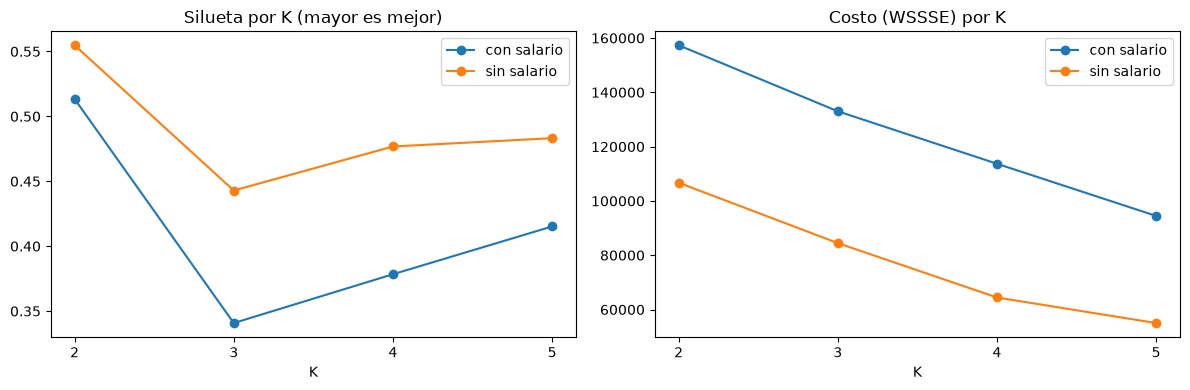

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for nombre, t in eval_k.groupby("variables"):
    ax1.plot(t["k"], t["silueta"], marker="o", label=nombre)
    ax2.plot(t["k"], t["costo"], marker="o", label=nombre)
ax1.set_title("Silueta por K (mayor es mejor)")
ax2.set_title("Costo (WSSSE) por K")
for ax in (ax1, ax2):
    ax.set_xlabel("K")
    ax.set_xticks([2, 3, 4, 5])
    ax.legend()
plt.tight_layout()
plt.show()

**¿Incluir el salario?** No. Para cualquier K, la silueta cae al agregarlo (con K=2 baja
de 0.55 a 0.51 y con K=3 de 0.44 a 0.34). Su cola larga genera grupos definidos por unos
pocos salarios extremos. Además, el objetivo es describir perfiles laborales, así que el
salario se usa después para caracterizar cada cluster y no para formarlo.

**Elección de K.** K=2 tiene la silueta más alta (0.55), pero solo separa a jóvenes de
mayores. Entre K=3, 4 y 5, el mejor es **K=5** (silueta 0.48), y el costo sigue bajando
sin un codo claro. Se elige K=5 porque separa bien los grupos y da perfiles más útiles.

### 4.1 Modelo final y descripción de los clusters

In [30]:
K_FINAL = 5
kmeans_final = KMeans(k=K_FINAL, seed=42, featuresCol="features").fit(datos_sin)
clusters = kmeans_final.transform(datos_sin).withColumnRenamed("prediction", "cluster")

perfil = (clusters.groupBy("cluster")
          .agg(F.count("*").alias("n"),
               *[F.round(F.mean(c), 1).alias(f"media_{c}") for c in VARS_SIN_SAL],
               F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
               F.round(100 * F.mean((F.col("categoria_ocupacional") == "1").cast("int")), 1)
                .alias("pct_gobierno"),
               F.round(100 * F.mean((F.col("categoria_ocupacional") == "3").cast("int")), 1)
                .alias("pct_jornalero"),
               F.round(100 * F.mean((F.col("categoria_ocupacional") == "4").cast("int")), 1)
                .alias("pct_domestico"))
          .withColumn("pct_registros", F.round(100 * F.col("n") / N_2025, 1))
          .orderBy("cluster").toPandas())
perfil

,cluster,n,media_edad,media_antiguedad,media_horas_semanales,salario_mediano,pct_gobierno,pct_jornalero,pct_domestico,pct_registros
0,0,22702,26.3,2.6,47.5,3200.0,6.8,25.3,4.1,42.8
1,1,6262,31.3,3.7,80.6,3000.0,9.4,17.8,5.6,11.8
2,2,6609,50.2,22.5,41.2,3800.0,31.4,22.3,5.9,12.5
3,3,6417,29.5,2.9,19.4,1200.0,14.6,40.1,17.2,12.1
4,4,11035,50.0,4.2,43.1,3200.0,13.0,26.6,10.1,20.8


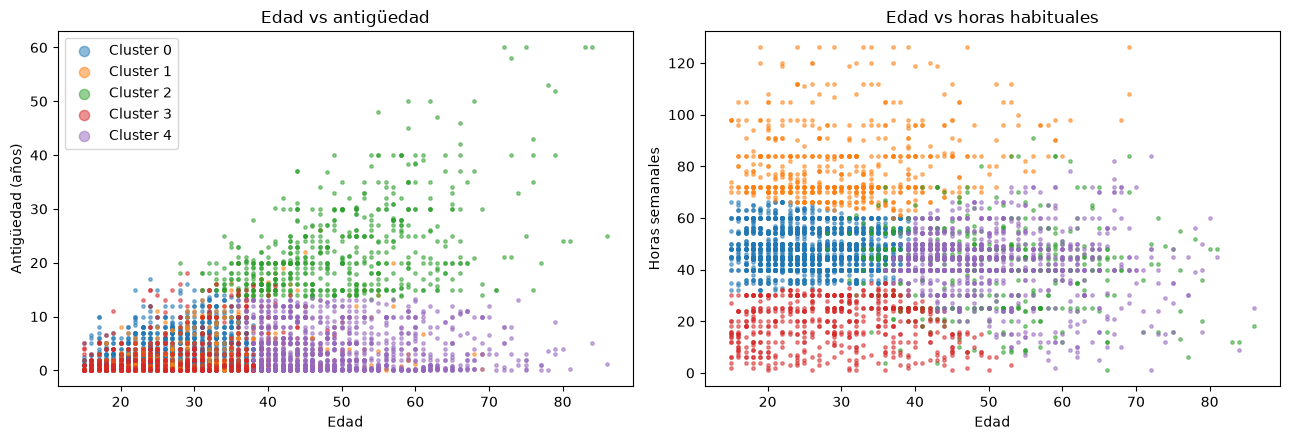

In [31]:
m = (clusters.select("edad", "antiguedad", "horas_semanales", "cluster")
             .sample(fraction=min(1.0, 5000 / N_2025), seed=42).toPandas())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for k, g in m.groupby("cluster"):
    ax1.scatter(g["edad"], g["antiguedad"], s=6, alpha=0.5, label=f"Cluster {k}")
    ax2.scatter(g["edad"], g["horas_semanales"], s=6, alpha=0.5, label=f"Cluster {k}")
ax1.set(xlabel="Edad", ylabel="Antigüedad (años)", title="Edad vs antigüedad")
ax2.set(xlabel="Edad", ylabel="Horas semanales", title="Edad vs horas habituales")
ax1.legend(markerscale=3)
plt.tight_layout()
plt.show()

**Descripción de los perfiles (K = 5).** Los números de cluster se identifican en la tabla
anterior por sus medias.

| Perfil | Rasgos | Salario mediano |
|---|---|---|
| **Jóvenes de jornada completa** (43 %) | ~26 años, 2.6 años de antigüedad, ~48 h semanales | Q3,200 |
| **Adultos con poca antigüedad** (21 %) | ~50 años pero solo ~4 años en el empleo; rotación o reingreso tardío | Q3,200 |
| **Veteranos estables** (12 %) | ~50 años, ~22 años de antigüedad, jornada normal; 31 % son de gobierno | Q3,800 |
| **Jornadas extensas** (12 %) | ~31 años, ~81 h semanales | Q3,000 |
| **Jornada parcial** (12 %) | ~30 años, ~19 h semanales; 40 % jornaleros y 17 % servicio doméstico | Q1,200 |

Los clusters se forman sobre todo por **edad, antigüedad y horas**. Aun así, el salario
los separa: los veteranos, más ligados al empleo público, ganan más, y el grupo de jornada
parcial gana menos de la mitad que el resto. Las jornadas extensas no ganan más que la
jornada completa, así que trabajar más horas no se traduce en mejor salario.